# Regex

In [47]:
import pandas as pd 
import requests 
import io 
import zipfile 
from io import BytesIO
import os

myurl="https://www.forexite.com/free_forex_quotes/2011/11/011111.zip"

dirForexite="data/raw/FX/intraday/forexite"
if not os.path.exists(dirForexite):
    os.makedirs("data/raw/FX/intraday/forexite")
    
myfile='data/raw/FX/intraday/forexite/011111.zip' 


In [48]:
FX=pd.read_csv(myurl)
FX.to_parquet("data/raw/FX/intraday/forexite/011111.parquet")     # requires fastparquet package
FX  

,<TICKER>,<DTYYYYMMDD>,<TIME>,<OPEN>,<HIGH>,<LOW>,<CLOSE>
0,EURUSD,20111101,100,1.3841,1.3842,1.3841,1.3841
1,EURUSD,20111101,200,1.3841,1.3841,1.3840,1.3840
2,EURUSD,20111101,300,1.3841,1.3841,1.3835,1.3836
3,EURUSD,20111101,400,1.3836,1.3836,1.3836,1.3836
4,EURUSD,20111101,500,1.3837,1.3837,1.3833,1.3835
...,...,...,...,...,...,...,...
73184,USXUSD,20111101,235600,77.3600,77.4200,77.3600,77.3900
73185,USXUSD,20111101,235700,77.3900,77.3900,77.3800,77.3800
73186,USXUSD,20111101,235800,77.3800,77.3900,77.3800,77.3900
73187,USXUSD,20111101,235900,77.4000,77.4200,77.4000,77.4200


In [52]:
import re
FX.columns=[re.sub(r"^<|>$","",mycol) for mycol in FX.columns]   # replaces < or > in the column names

In [54]:
# the pandas way
FX["TICKER"] = FX["TICKER"].replace('^(\w{3})(\w{3})$',r'\1/\2',regex=True)

In [55]:
FX["TIME"]=["%06d" % myval for myval in FX["TIME"].values.astype(int)]   # adds the padding 0s in the TIME column


In [56]:
# looks good 
FX

,TICKER,DTYYYYMMDD,TIME,OPEN,HIGH,LOW,CLOSE
0,EUR/USD,20111101,000100,1.3841,1.3842,1.3841,1.3841
1,EUR/USD,20111101,000200,1.3841,1.3841,1.3840,1.3840
2,EUR/USD,20111101,000300,1.3841,1.3841,1.3835,1.3836
3,EUR/USD,20111101,000400,1.3836,1.3836,1.3836,1.3836
4,EUR/USD,20111101,000500,1.3837,1.3837,1.3833,1.3835
...,...,...,...,...,...,...,...
73184,USX/USD,20111101,235600,77.3600,77.4200,77.3600,77.3900
73185,USX/USD,20111101,235700,77.3900,77.3900,77.3800,77.3800
73186,USX/USD,20111101,235800,77.3800,77.3900,77.3800,77.3900
73187,USX/USD,20111101,235900,77.4000,77.4200,77.4000,77.4200


In [19]:
FX.index=pd.to_datetime(FX["DTYYYYMMDD"].map(str)+" "+FX["TIME"],
               format="%Y%m%d %H%M%S",
              utc=True)                              # converts the DTYYYYMMDD and TIME columns into datetime, and sets the index

# Categorical plots


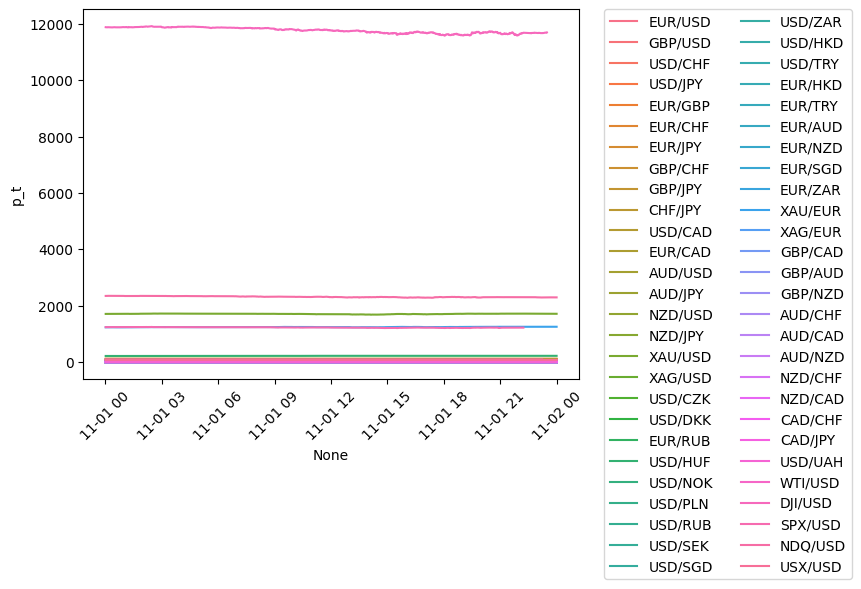

<Figure size 640x480 with 0 Axes>

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt
#from pandas.plotting import register_matplotlib_converters  # avoids a warning about timezones
#register_matplotlib_converters()

#sns.set()   # set default style

sns.lineplot(x=FX.index,y="CLOSE",  hue="TICKER",data=FX)     # one color (hue) per TICKER
plt.xticks(rotation=45)                                        # avoids overlapping x labels
plt.ylabel(r'p_t')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., ncol=2)  # it is quite hard to see anything because of the large diversity of y scales
plt.show()
plt.savefig("FX_notscaled.pdf")

In [26]:
normalize_price=lambda x: x/x.iloc[0]   # divides a vector by its first value. Note the x.iloc, because the transform receives a pandas
FX["normalized_close"]=FX[ ["TICKER","CLOSE"] ].groupby("TICKER").transform(normalize_price)   

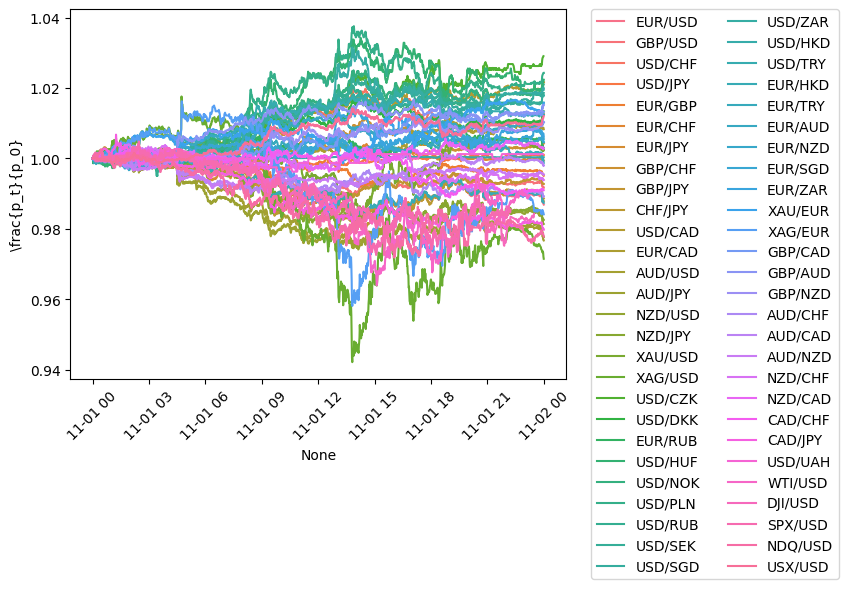

In [30]:
sns.lineplot(x=FX.index,y="normalized_close",hue="TICKER",data=FX)
plt.xticks(rotation=45) 
plt.ylabel(r'\frac{p_t}{p_0}')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.,ncol=2)

## Polars

In [94]:
import polars as pl

# https://github.com/pola-rs/polars/issues/19447   polars cannot read zip files directly

FX=pl.DataFrame(pd.read_csv(myurl))   # reads the csv file using pandas, then converts to polars DataFrame
FX.columns=[re.sub(r"^<|>$","",mycol) for mycol in FX.columns]   # replaces < or > in the column names
FX=FX.with_columns(pl.col("TIME").cast(pl.Utf8).str.zfill(6))   # adds the padding 0s in the TIME column
FX

TICKER,DTYYYYMMDD,TIME,OPEN,HIGH,LOW,CLOSE
str,i64,str,f64,f64,f64,f64
"""EURUSD""",20111101,"""000100""",1.3841,1.3842,1.3841,1.3841
"""EURUSD""",20111101,"""000200""",1.3841,1.3841,1.384,1.384
"""EURUSD""",20111101,"""000300""",1.3841,1.3841,1.3835,1.3836
"""EURUSD""",20111101,"""000400""",1.3836,1.3836,1.3836,1.3836
"""EURUSD""",20111101,"""000500""",1.3837,1.3837,1.3833,1.3835
…,…,…,…,…,…,…
"""USXUSD""",20111101,"""235600""",77.36,77.42,77.36,77.39
"""USXUSD""",20111101,"""235700""",77.39,77.39,77.38,77.38
"""USXUSD""",20111101,"""235800""",77.38,77.39,77.38,77.39


In [96]:
FX=FX.with_columns(pl.col("TICKER").str.replace_all('^(\w{3})(\w{3})$',r'$1/$2',))   # polars use $1 instead of \1
FX

TICKER,DTYYYYMMDD,TIME,OPEN,HIGH,LOW,CLOSE
str,i64,str,f64,f64,f64,f64
"""EUR/USD""",20111101,"""000100""",1.3841,1.3842,1.3841,1.3841
"""EUR/USD""",20111101,"""000200""",1.3841,1.3841,1.384,1.384
"""EUR/USD""",20111101,"""000300""",1.3841,1.3841,1.3835,1.3836
"""EUR/USD""",20111101,"""000400""",1.3836,1.3836,1.3836,1.3836
"""EUR/USD""",20111101,"""000500""",1.3837,1.3837,1.3833,1.3835
…,…,…,…,…,…,…
"""USX/USD""",20111101,"""235600""",77.36,77.42,77.36,77.39
"""USX/USD""",20111101,"""235700""",77.39,77.39,77.38,77.38
"""USX/USD""",20111101,"""235800""",77.38,77.39,77.38,77.39


In [97]:
FX=FX.with_columns(
    pl.concat_str([
        pl.col("DTYYYYMMDD").cast(pl.Utf8),
        pl.lit(" "),
        pl.col("TIME")
    ]).str.strptime(pl.Datetime, format="%Y%m%d %H%M%S")
    .dt.replace_time_zone("UTC")
    .alias("datetime")
)  # creates a datetime column


In [98]:
FX

TICKER,DTYYYYMMDD,TIME,OPEN,HIGH,LOW,CLOSE,datetime
str,i64,str,f64,f64,f64,f64,"datetime[μs, UTC]"
"""EUR/USD""",20111101,"""000100""",1.3841,1.3842,1.3841,1.3841,2011-11-01 00:01:00 UTC
"""EUR/USD""",20111101,"""000200""",1.3841,1.3841,1.384,1.384,2011-11-01 00:02:00 UTC
"""EUR/USD""",20111101,"""000300""",1.3841,1.3841,1.3835,1.3836,2011-11-01 00:03:00 UTC
"""EUR/USD""",20111101,"""000400""",1.3836,1.3836,1.3836,1.3836,2011-11-01 00:04:00 UTC
"""EUR/USD""",20111101,"""000500""",1.3837,1.3837,1.3833,1.3835,2011-11-01 00:05:00 UTC
…,…,…,…,…,…,…,…
"""USX/USD""",20111101,"""235600""",77.36,77.42,77.36,77.39,2011-11-01 23:56:00 UTC
"""USX/USD""",20111101,"""235700""",77.39,77.39,77.38,77.38,2011-11-01 23:57:00 UTC
"""USX/USD""",20111101,"""235800""",77.38,77.39,77.38,77.39,2011-11-01 23:58:00 UTC


In [99]:
# suggested by Claude 4.5

FX =FX.group_by("TICKER").agg([pl.col("CLOSE").first().alias("first_close")]).join(FX, on="TICKER")  # joins the first close price per TICKER
FX=FX.with_columns( (pl.col("CLOSE")/pl.col("first_close")).alias("normalized_close") )  # computes the normalized close price
FX

TICKER,first_close,DTYYYYMMDD,TIME,OPEN,HIGH,LOW,CLOSE,datetime,normalized_close
str,f64,i64,str,f64,f64,f64,f64,"datetime[μs, UTC]",f64
"""EUR/USD""",1.3841,20111101,"""000100""",1.3841,1.3842,1.3841,1.3841,2011-11-01 00:01:00 UTC,1.0
"""EUR/USD""",1.3841,20111101,"""000200""",1.3841,1.3841,1.384,1.384,2011-11-01 00:02:00 UTC,0.999928
"""EUR/USD""",1.3841,20111101,"""000300""",1.3841,1.3841,1.3835,1.3836,2011-11-01 00:03:00 UTC,0.999639
"""EUR/USD""",1.3841,20111101,"""000400""",1.3836,1.3836,1.3836,1.3836,2011-11-01 00:04:00 UTC,0.999639
"""EUR/USD""",1.3841,20111101,"""000500""",1.3837,1.3837,1.3833,1.3835,2011-11-01 00:05:00 UTC,0.999567
…,…,…,…,…,…,…,…,…,…
"""USX/USD""",76.52,20111101,"""235600""",77.36,77.42,77.36,77.39,2011-11-01 23:56:00 UTC,1.01137
"""USX/USD""",76.52,20111101,"""235700""",77.39,77.39,77.38,77.38,2011-11-01 23:57:00 UTC,1.011239
"""USX/USD""",76.52,20111101,"""235800""",77.38,77.39,77.38,77.39,2011-11-01 23:58:00 UTC,1.01137


In [100]:
# suggested by me 

#FX.group_by("TICKER").agg(pl.col("CLOSE")/pl.col("CLOSE").first()) # warning: by default polars replaces pl.col("CLOSE") 
                                                                   # by the result of the computation

In [116]:

FX.group_by("TICKER").agg((pl.col("CLOSE")/pl.col("CLOSE").first()).alias("normalize_close"))     # alias of the whole parenthesis

TICKER,normalize_close
str,list[f64]
"""EUR/NZD""","[1.0, 0.999942, … 1.005484]"
"""EUR/CAD""","[1.0, 1.0, … 1.008312]"
"""USD/SEK""","[1.0, 1.000154, … 1.018598]"
"""NDQ/USD""","[1.0, 1.0, … 0.977853]"
"""EUR/USD""","[1.0, 0.999928, … 0.986923]"
…,…
"""USD/HKD""","[1.0, 1.0, … 1.000348]"
"""GBP/AUD""","[1.0, 1.000131, … 1.015159]"
"""SPX/USD""","[1.0, 1.000805, … 0.985507]"


In [117]:
FX.group_by("TICKER").agg((pl.col("CLOSE")/pl.col("CLOSE").first())).explode("CLOSE")   # alternative way to compute the normalized close price

TICKER,CLOSE
str,f64
"""GBP/USD""",1.0
"""GBP/USD""",1.0
"""GBP/USD""",0.999938
"""GBP/USD""",0.999751
"""GBP/USD""",0.999813
…,…
"""USD/SGD""",1.017937
"""USD/SGD""",1.017937
"""USD/SGD""",1.017937


In [115]:
# suggested by me 

FX.group_by("TICKER").agg([pl.col("datetime"),(pl.col("CLOSE")/pl.col("CLOSE").first()).alias("normalized_close")]).explode(["datetime","normalized_close"])     # alias of the whole parenthesis

TICKER,datetime,normalized_close
str,"datetime[μs, UTC]",f64
"""USD/HKD""",2011-11-01 00:01:00 UTC,1.0
"""USD/HKD""",2011-11-01 00:02:00 UTC,1.0
"""USD/HKD""",2011-11-01 00:03:00 UTC,1.0
"""USD/HKD""",2011-11-01 00:04:00 UTC,1.0
"""USD/HKD""",2011-11-01 00:05:00 UTC,1.0
…,…,…
"""GBP/JPY""",2011-11-01 23:56:00 UTC,0.992922
"""GBP/JPY""",2011-11-01 23:57:00 UTC,0.992922
"""GBP/JPY""",2011-11-01 23:58:00 UTC,0.992922
